# BI - Laboratorio 2
* Santiago Casasbuenas - 202214932
* Manuel Gomez - 202020415
* Juan Pablo Castro - 20222086

## 0. Imports


In [ ]:
%matplotlib inline

In [48]:
# -------------------------------------------
# Librerías para manipulación y cálculo numérico
import numpy as np
import pandas as pd

# Configuración de pandas para visualizar más filas y columnas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

# -------------------------------------------
# Utilidades para guardar y cargar modelos
from joblib import dump, load

# -------------------------------------------
# Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------
# Herramientas de scikit-learn para preparación de datos y modelado
# División de datos, regresión lineal y creación de pipelines y transformaciones
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# Métricas para evaluar el modelo de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------
# Funciones estadísticas adicionales
import scipy.stats as stats

# -------------------------------------------
from sklearn.cluster import KMeans

# Librerías para análisis de datos
#from ydata_profiling import ProfileReport

## 1. Carga de datos
En esta sección se explica cómo se carga el conjunto de datos que se utilizará a lo largo del laboratorio. Se suele emplear la función pd.read_csv (o funciones similares) para leer archivos con formato CSV, Excel u otros, permitiendo convertir la información en un DataFrame de pandas. Así, se asegura que la data esté disponible para realizar análisis exploratorio, procesamiento y modelado posterior.

In [11]:
# Carga de datos
customer_df = pd.read_csv("./Customer_Data.csv", encoding="ISO-8859-1", sep=";")    

In [12]:
#Información general del dataset
customer_df.shape

(8950, 18)

## 2. Entendimiento de los datos
Se llevará a cabo un perfilamiento de los datos utilizando pandas_profiling para obtener una visión general del conjunto de datos e identificar posibles problemas en variables específicas y sus relaciones. Posteriormente, se realizará un análisis numérico mediante gráficos de dispersión e histogramas, con el fin de estudiar la distribución y la correlación de las variables cuantitativas. Dado que el conjunto de datos no contiene variables categóricas, el análisis se centrará exclusivamente en las variables numéricas.


#### 2.1. Análisis Numérico - Gráficas de dispersión e histogramas
En esta sección se explorará la distribución y relaciones de las variables numéricas del conjunto de datos. Se utilizarán gráficas de dispersión para visualizar la relación entre pares de variables de interés y detectar patrones o posibles outliers. Asimismo, se generarán histogramas para analizar la distribución de cada variable, permitiendo identificar sesgos o concentraciones inusuales. Estas visualizaciones serán fundamentales para entender el comportamiento de la data antes de proceder con transformaciones o modelado.

In [14]:
numericas = [
    "SALDO", "F_SALDO", "COMPRAS", "COMPRAS_PUNTUALES", "COMPRAS_PLAZOS", 
    "AVANCE_EFECTIVO", "F_COMPRAS", "F_COMPRAS_PUNTUALES", "F_COMPRAS_PLAZOS", 
    "F_AVANCE_EFECTIVO", "P_AVANCE_EFECTIVO", "P_COMPRAS", "LÍMITE_CREDITO", 
    "PAGOS", "PAGOS_MINIMOS", "F_PAGOS_COMPLETOS", "MESES_CLIENTE"
]

##### 2.1.1. Gráficas de dispersión

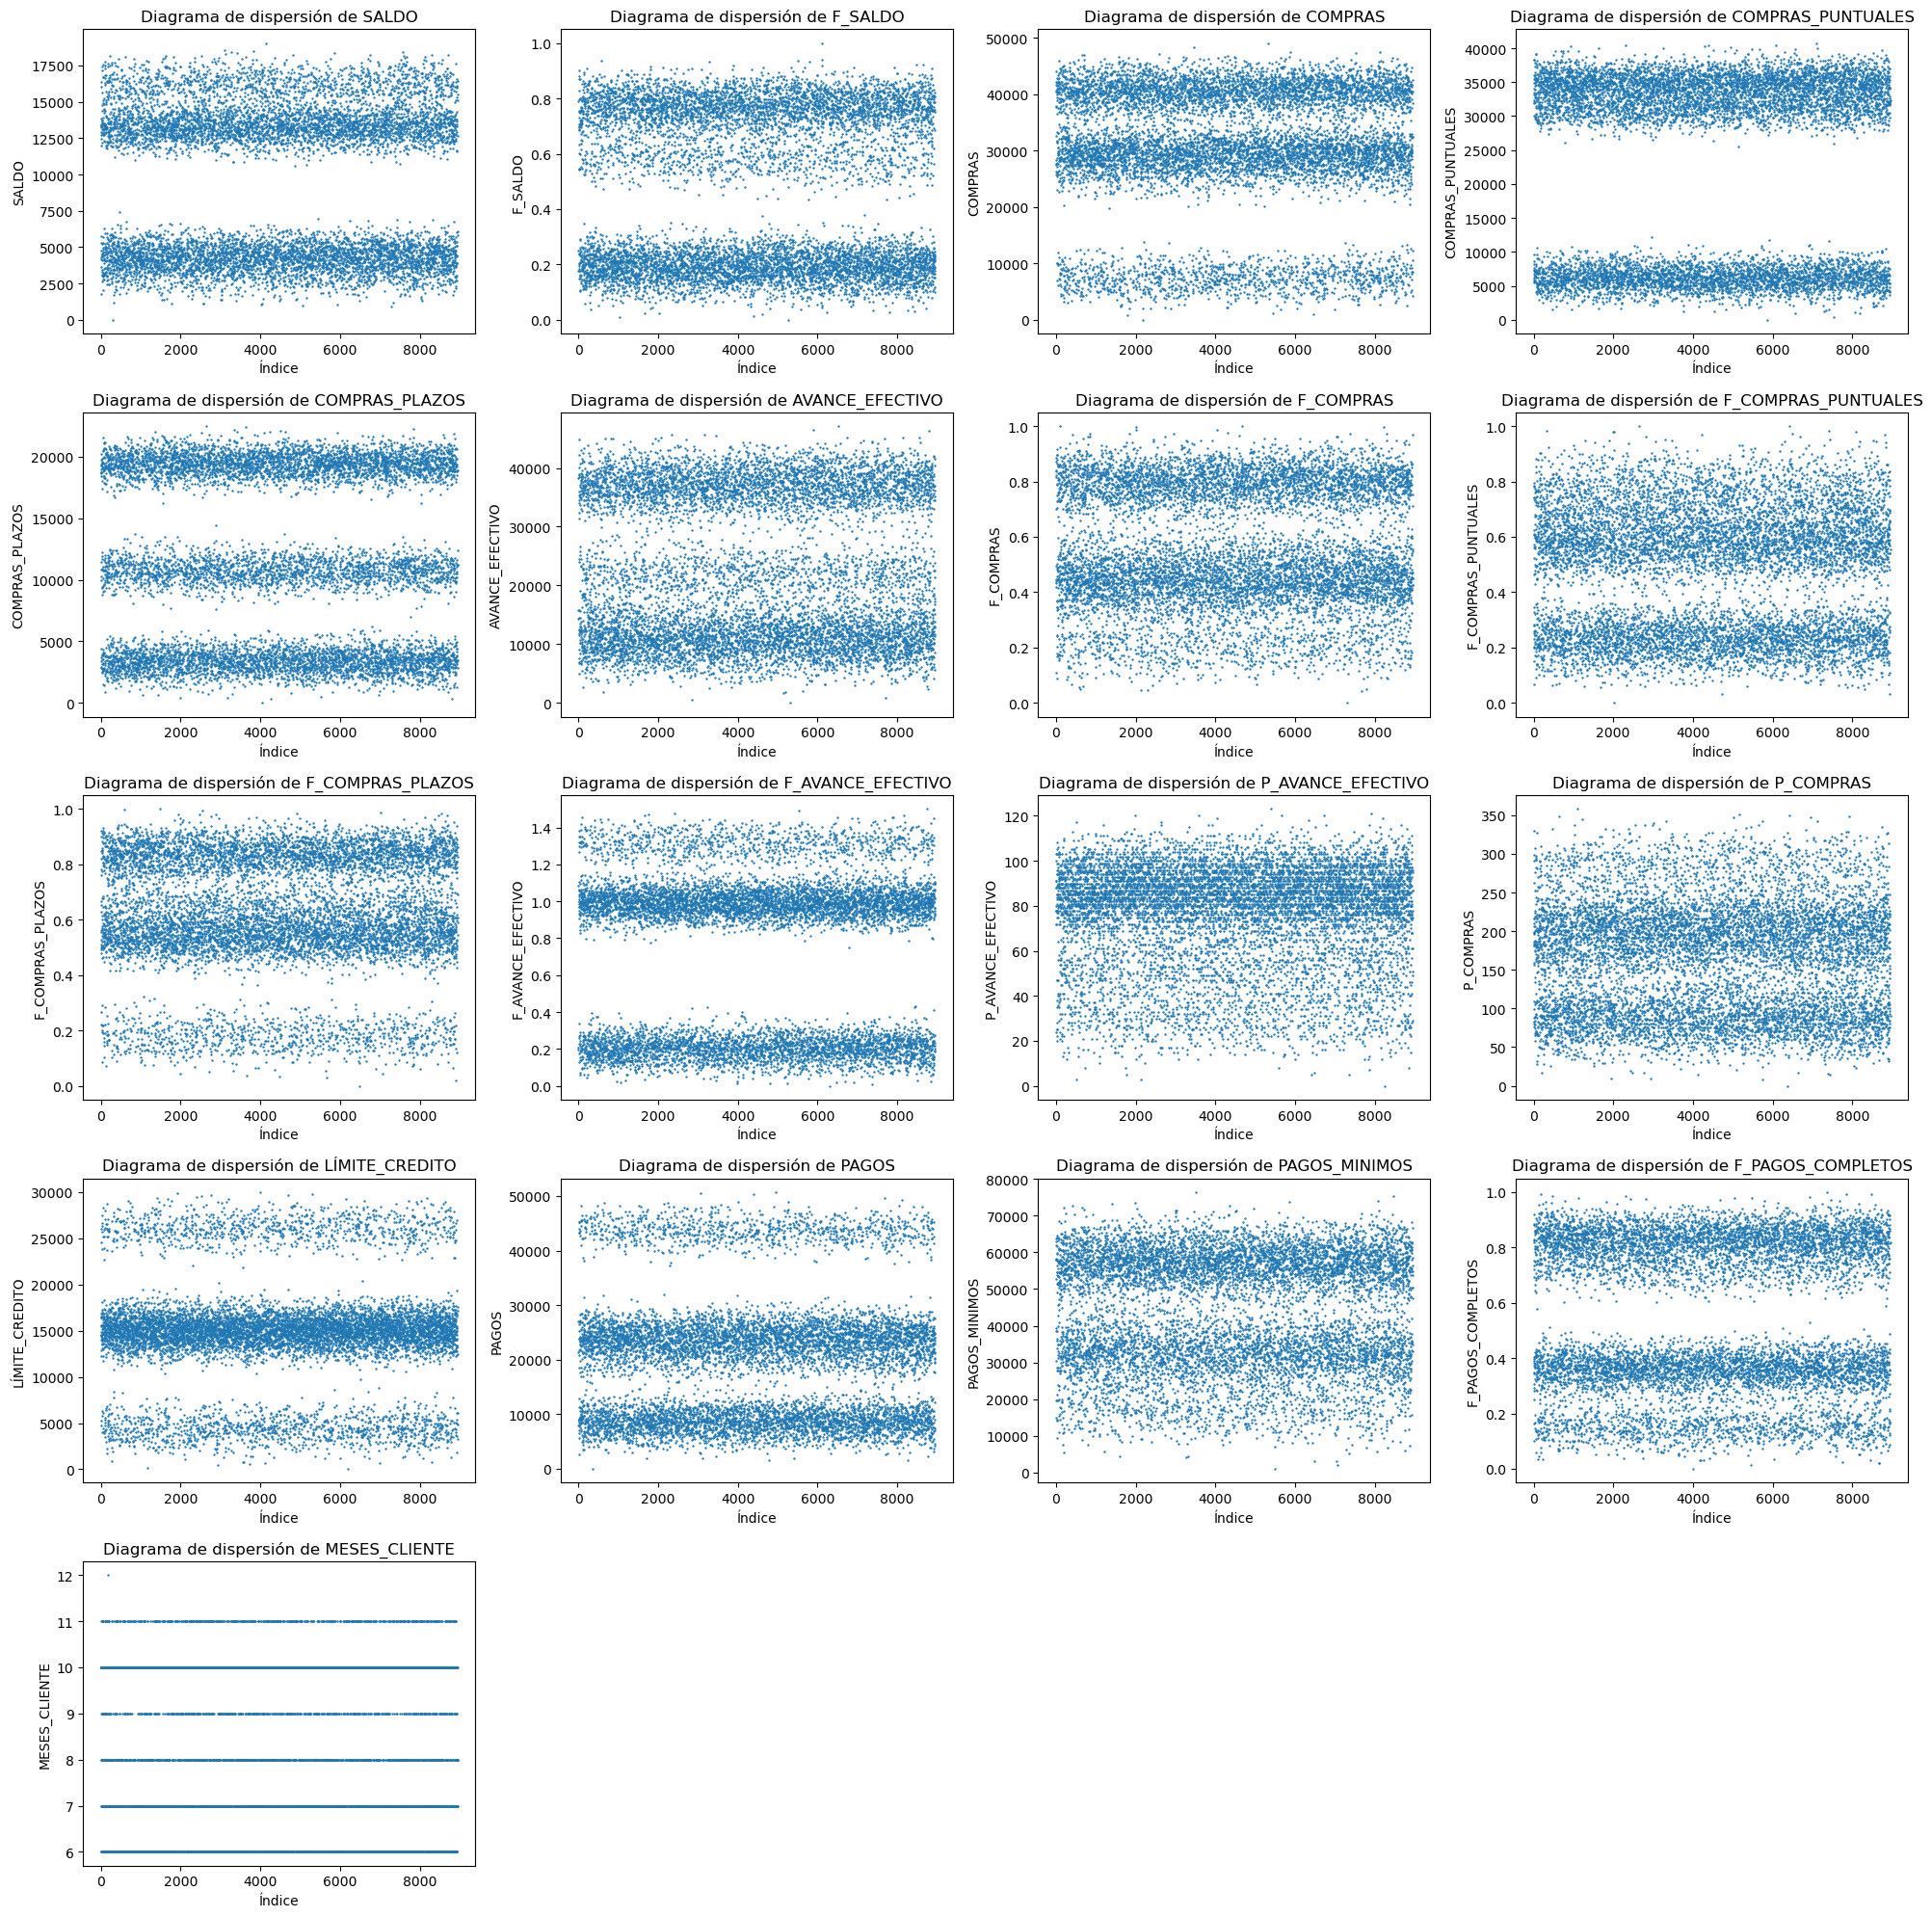

In [ ]:
# Calcular el número de filas necesarias en base a columnas por fila
columnas_por_fila = 4
filas = int(np.ceil(len(numericas) / columnas_por_fila))
figura, ejes = plt.subplots(filas, columnas_por_fila, figsize=(columnas_por_fila * 5, filas * 4))
ejes = ejes.flatten()

# Graficar cada columna numérica en un subplot separado
for eje, columna in zip(ejes, numericas):
    eje.scatter(customer_df.index, customer_df[columna],s=0.5) # s es el tamaño de los puntos
    eje.set_xlabel("Índice")
    eje.set_ylabel(columna)
    eje.set_title(f"Diagrama de dispersión de {columna}")

# Ocultar subplots extras
for eje in ejes[len(numericas):]:
    eje.set_visible(False)

plt.tight_layout()
plt.show()

##### 2.1.2 Histogramas

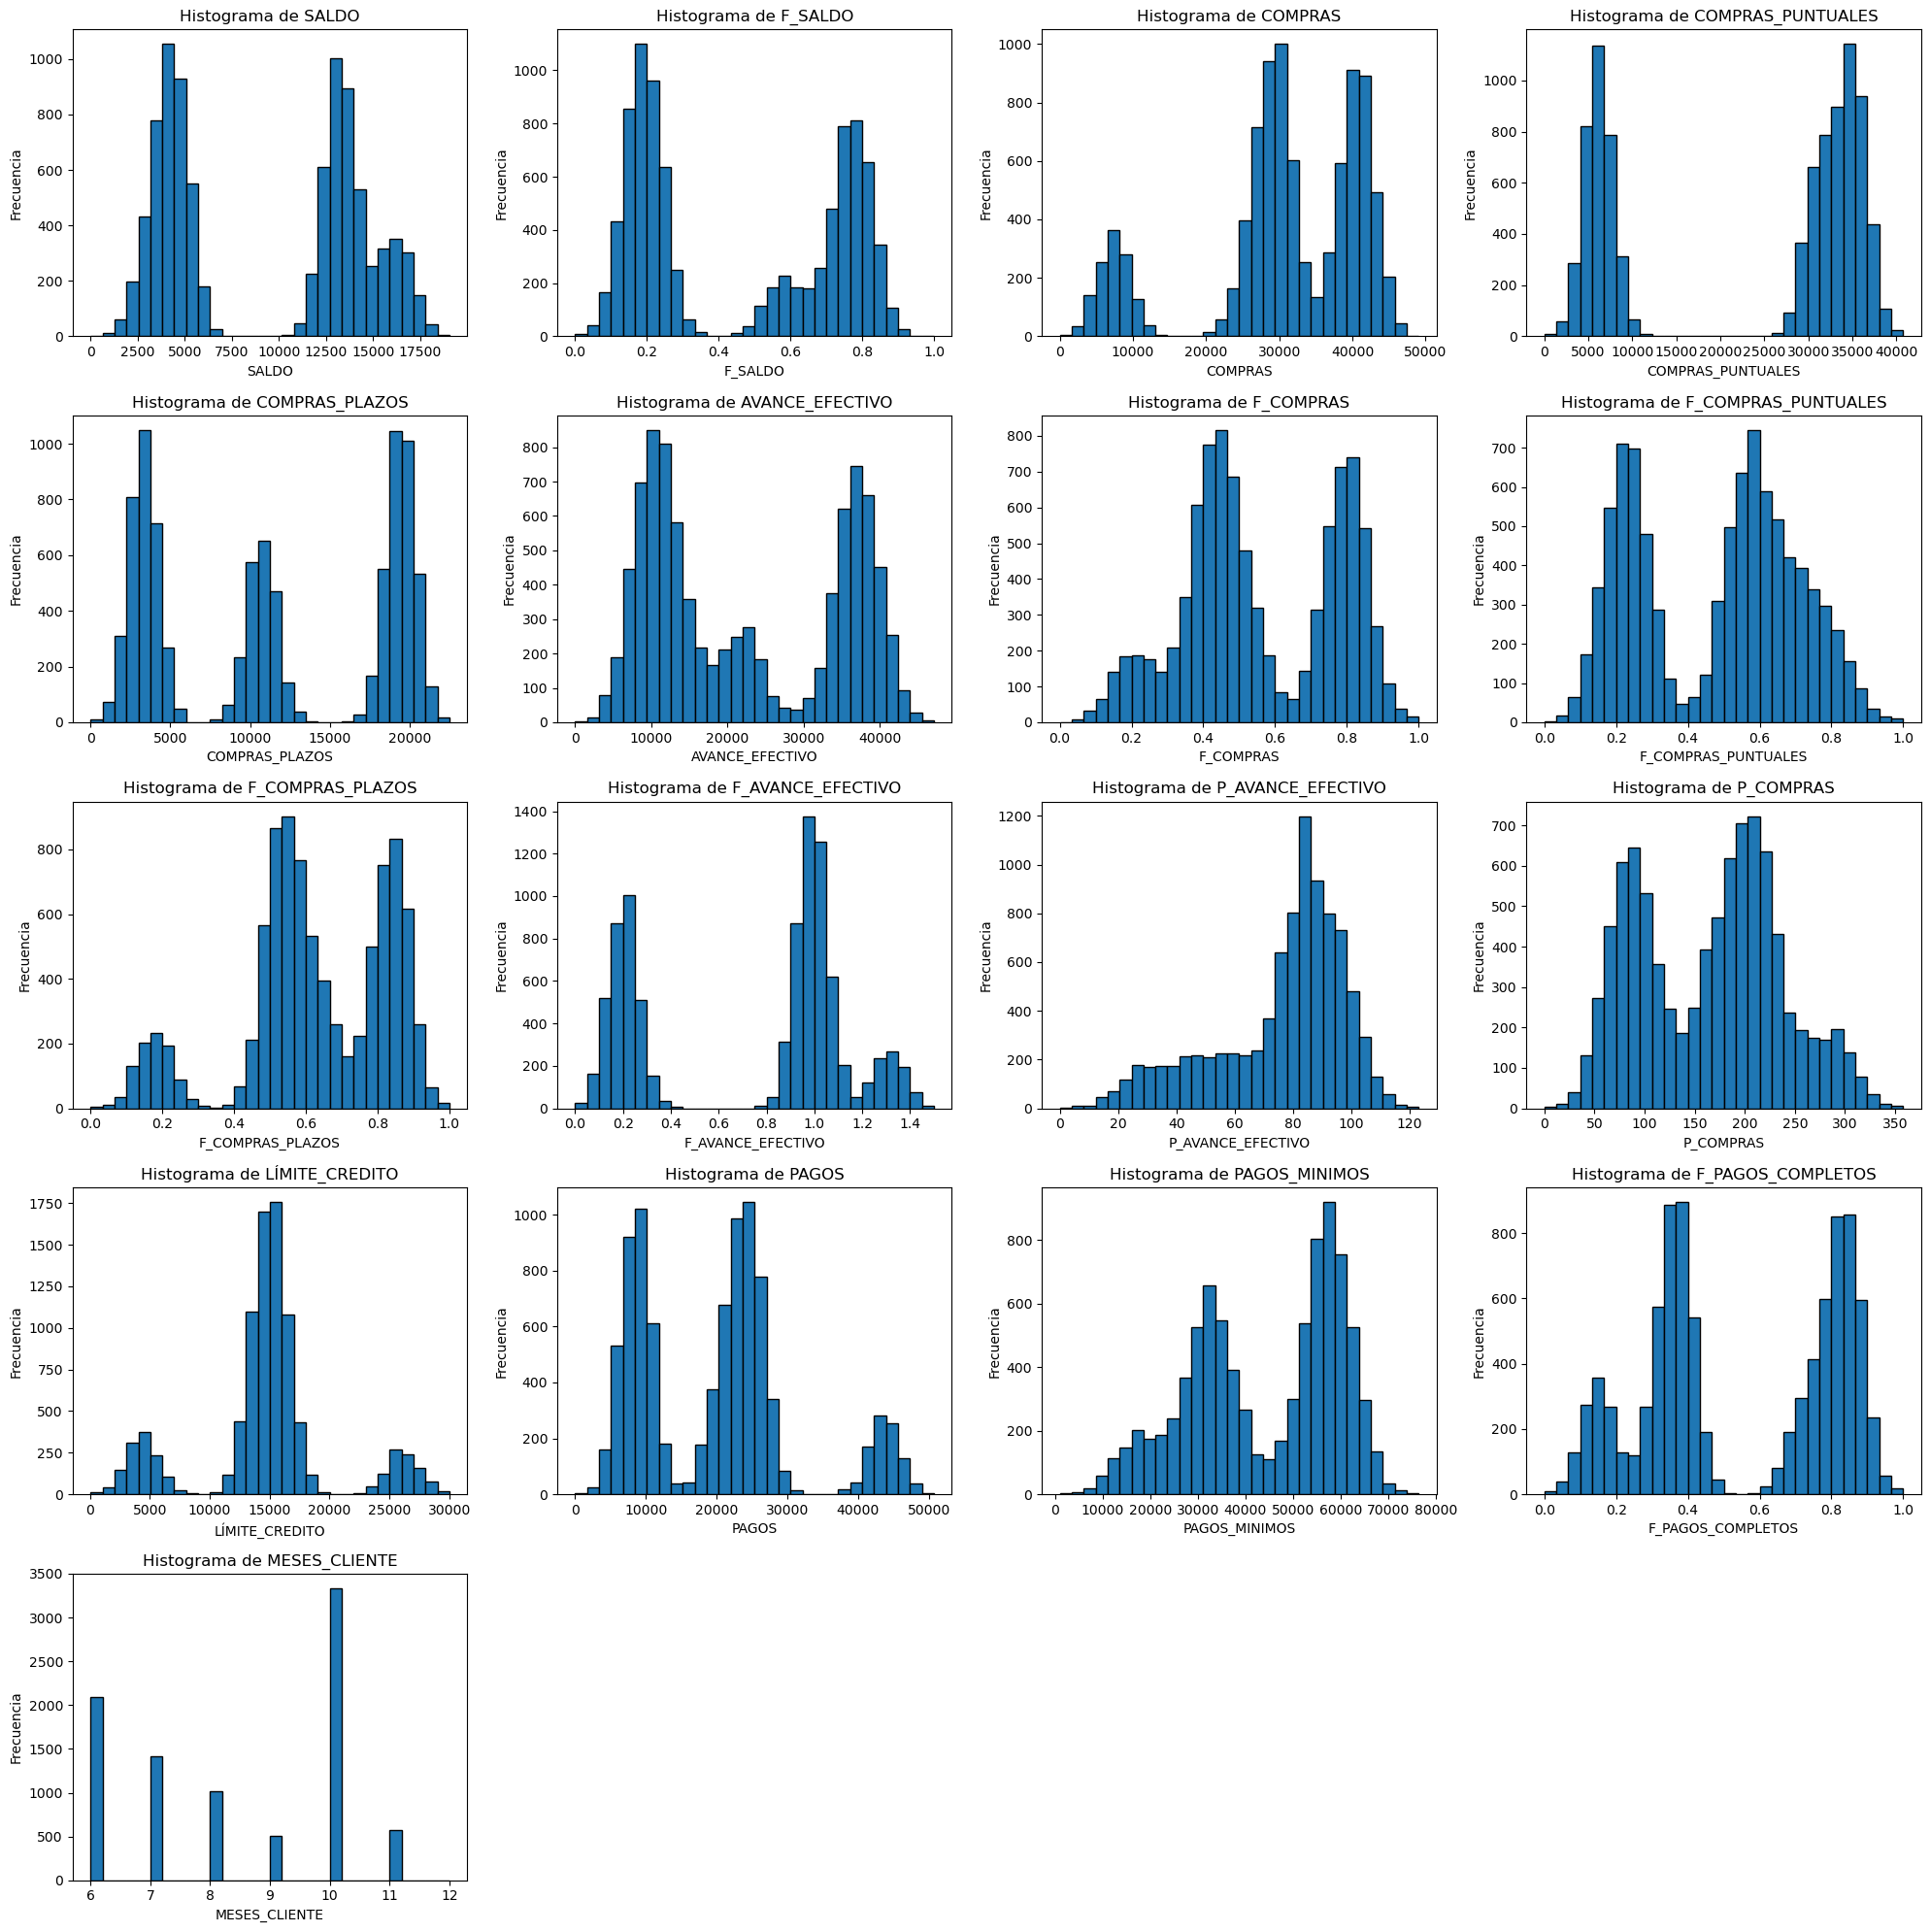

In [19]:
# Generar histogramas para cada variable numérica
filas_histo = int(np.ceil(len(numericas) / columnas_por_fila))
fig, axes_hist = plt.subplots(filas_histo, columnas_por_fila, figsize=(columnas_por_fila * 5, filas_histo * 4))
axes_hist = axes_hist.flatten()

for ax, col in zip(axes_hist, numericas):
    ax.hist(customer_df[col], bins=30, edgecolor='black')
    ax.set_title(f"Histograma de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

# Ocultar los subplots vacíos si existen
for ax in axes_hist[len(numericas):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

##### 2.1.3 Conlcusiones iniciales sobre las variables numéricas
A partir del análisis visual de las gráficas, se identifican valores atípicos en algunas variables, particularmente en F_AVANCE_EFECTIVO, donde se observan registros por encima de 1, a pesar de que el diccionario de datos establece que su rango debe estar entre 0 y 1. De manera similar, otras variables con rangos acotados a este intervalo presentan valores fuera de los límites, aunque en menor medida. Además, tanto en los histogramas como en los diagramas de dispersión, se pueden distinguir patrones de agrupación, lo que indica que ciertos conjuntos de datos comparten características similares y podrían representar distintos perfiles de clientes.

### 2.2. Análisis del perfilamiento
En esta sección se analizarán los valores nulos, los registros duplicados y la presencia de posibles outliers. Además, se examinará la correlación entre las variables. Este análisis proporcionará una visión más detallada sobre la calidad de los datos, permitiendo detectar patrones y anomalías que no son fácilmente visibles en las gráficas tradicionales.

#### 2.2.1. Análisis de filas duplicadas.

In [25]:
# Mostrar todas las filas duplicadas en el DataFrame
filas_duplicadas = customer_df[customer_df.duplicated(keep=False)]
print(filas_duplicadas)

# Contar la cantidad de filas duplicadas (considerando solo la primera aparición como no duplicada)
cantidad_duplicados = customer_df.duplicated().sum()
print("\n----------------------------------------------------")
print(f"Cantidad de filas duplicadas: {cantidad_duplicados}")
print("------------------------------------------------------")

Empty DataFrame
Columns: [ID, SALDO, F_SALDO, COMPRAS, COMPRAS_PUNTUALES, COMPRAS_PLAZOS, AVANCE_EFECTIVO, F_COMPRAS, F_COMPRAS_PUNTUALES, F_COMPRAS_PLAZOS, F_AVANCE_EFECTIVO, P_AVANCE_EFECTIVO, P_COMPRAS, LÍMITE_CREDITO, PAGOS, PAGOS_MINIMOS, F_PAGOS_COMPLETOS, MESES_CLIENTE]
Index: []

----------------------------------------------------
Cantidad de filas duplicadas: 0
------------------------------------------------------


No se presentan filas duplicadas en los datos.

#### 2.2.2. Análisis de correlación

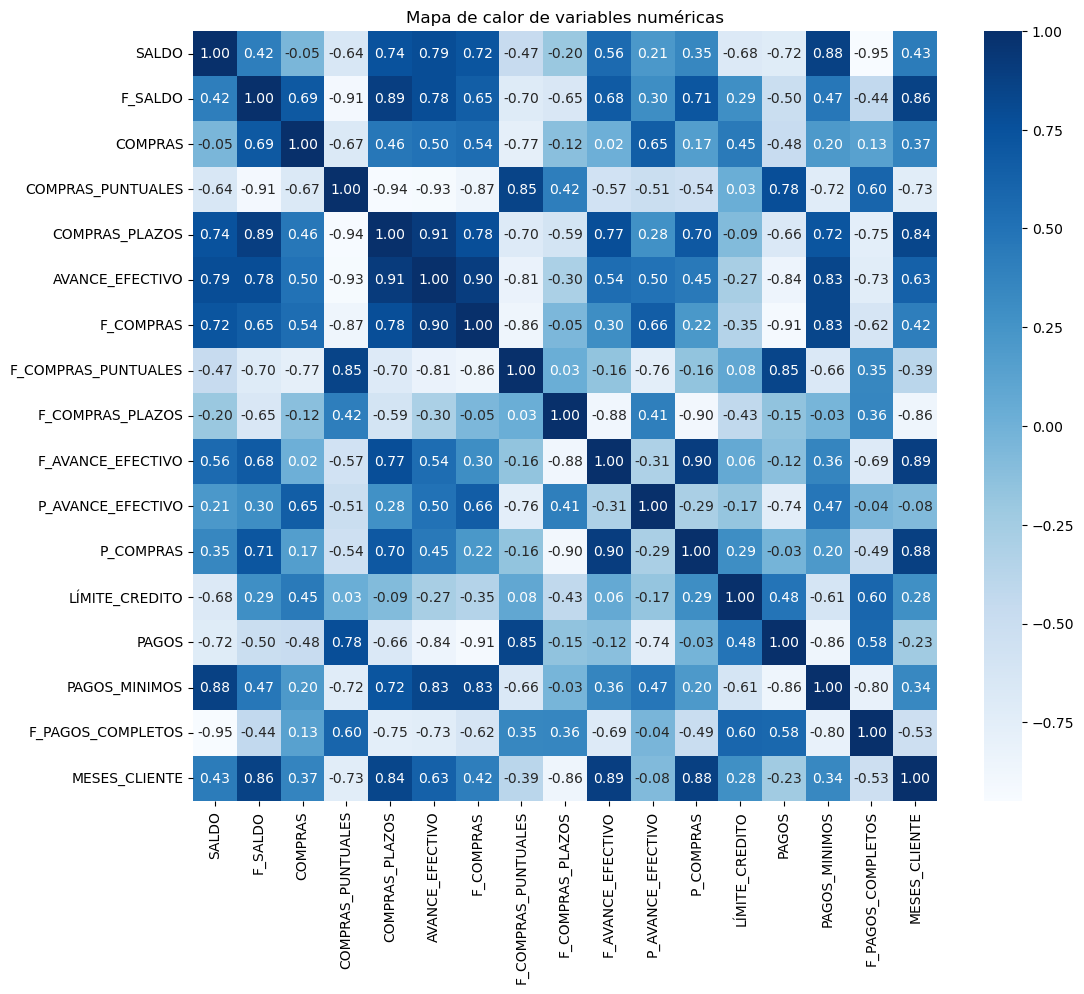

In [27]:
corr_matrix = customer_df[numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Mapa de calor de variables numéricas")
plt.show()

**Alta correlación entre variables**

- **Problema**: Se observa una alta correlación entre ciertas variables, lo que puede indicar redundancia en la información y afectar el desempeño del modelo de agrupamiento. La presencia de variables altamente relacionadas podría sesgar la segmentación y reducir la diversidad de los grupos formados.

  - SALDO con AVANCE_EFECTIVO y PAGOS  
  - F_SALDO con COMPRAS_PLAZOS y MESES_CLIENTE  
  - COMPRAS_PUNTUALES con F_COMPRAS_PUNTUALES  
  - COMPRAS_PLAZOS con AVANCE_EFECTIVO  
  - AVANCE_EFECTIVO con F_COMPRAS y PAGOS_MINIMOS  
  - F_COMPRAS con PAGOS_MINIMOS  
  - F_COMPRAS_PUNTUALES con PAGOS  
  - F_AVANCE_EFECTIVO con P_COMPRAS y MESES_CLIENTE  
  - P_COMPRAS con MESES_CLIENTE  

- **Acción:** Se van a tomar las variables que se consideren más importantes para resolver el problema del negocio.


### 2.3 Análisis de Calidad

En esta sección se evaluará la calidad de los datos mediante el análisis de los siguientes aspectos clave:
- **Completitud:** Se revisarán las variables para identificar posibles valores nulos o ausentes y así determinar la integridad de la información.

- **Unicidad:** Se verificará la existencia de registros duplicados, lo que podría afectar la fiabilidad de los análisis posteriores.

- **Consistencia:** Se analizarán las discrepancias entre los datos, buscando inconsistencias que indiquen errores o fallos en la recolección.

- **Validez:** Se comprobará que los valores cumplan con los formatos y restricciones esperados, asegurando que los datos sean confiables y relevantes para el problema a resolver.

#### 2.3.1 Análisis de Completitud

In [29]:
# Análisis de completitud: conteo y porcentaje de valores nulos en cada columna
faltantes = customer_df.isnull().sum()
porcentaje_faltante = 100 * customer_df.isnull().sum() / len(customer_df)
completitud = pd.DataFrame({
    "Valores faltantes": faltantes,
    "Porcentaje (%)": porcentaje_faltante
})
print(completitud)

                     Valores faltantes  Porcentaje (%)
ID                                   0        0.000000
SALDO                                0        0.000000
F_SALDO                              0        0.000000
COMPRAS                              0        0.000000
COMPRAS_PUNTUALES                    0        0.000000
COMPRAS_PLAZOS                       0        0.000000
AVANCE_EFECTIVO                      0        0.000000
F_COMPRAS                            0        0.000000
F_COMPRAS_PUNTUALES                  0        0.000000
F_COMPRAS_PLAZOS                     0        0.000000
F_AVANCE_EFECTIVO                    0        0.000000
P_AVANCE_EFECTIVO                    0        0.000000
P_COMPRAS                            0        0.000000
LÍMITE_CREDITO                       1        0.011173
PAGOS                                0        0.000000
PAGOS_MINIMOS                      313        3.497207
F_PAGOS_COMPLETOS                    0        0.000000
MESES_CLIE

En general, la completitud de los datos es alta, con excepción de la variable PAGOS_MINIMOS, que presenta más de 300 valores faltantes. Por otro lado, en LIMITE_CREDITO hay un único dato faltante, el cual no se considera significativo debido al tamaño del conjunto de datos.

### 2.3.2. Análisis de unicidad

In [30]:
# Análisis de unicidad en español

# Número total de filas
total_filas = customer_df.shape[0]
print("Número total de filas:", total_filas)

# Número de filas duplicadas
filas_duplicadas = customer_df.duplicated().sum()
print("Número de filas duplicadas:", filas_duplicadas)
print(f"Porcentaje de filas duplicadas: {100 * filas_duplicadas / total_filas:.2f}%")

# Análisis de unicidad por columna: número de valores únicos en cada una
print("\nNúmero de valores únicos por columna:")
unicidad = customer_df.nunique()
print(unicidad)

Número total de filas: 8950
Número de filas duplicadas: 0
Porcentaje de filas duplicadas: 0.00%

Número de valores únicos por columna:
ID                     8950
SALDO                  8949
F_SALDO                8950
COMPRAS                8950
COMPRAS_PUNTUALES      8950
COMPRAS_PLAZOS         8950
AVANCE_EFECTIVO        8950
F_COMPRAS              8950
F_COMPRAS_PUNTUALES    8950
F_COMPRAS_PLAZOS       8950
F_AVANCE_EFECTIVO      8950
P_AVANCE_EFECTIVO       118
P_COMPRAS               331
LÍMITE_CREDITO         8949
PAGOS                  8950
PAGOS_MINIMOS          8637
F_PAGOS_COMPLETOS      8950
MESES_CLIENTE             7
dtype: int64


#### 2.3.3 Análisis de Consistencia y Validez

In [ ]:
# a) Verificar que no existan valores negativos en columnas donde no deberían
columnas_sin_negativos = [
    "SALDO", "F_SALDO", "COMPRAS", "COMPRAS_PUNTUALES", "COMPRAS_PLAZOS", 
    "AVANCE_EFECTIVO", "F_COMPRAS", "F_COMPRAS_PUNTUALES", "F_COMPRAS_PLAZOS", 
    "F_AVANCE_EFECTIVO", "P_AVANCE_EFECTIVO", "P_COMPRAS", "LÍMITE_CREDITO", 
    "PAGOS", "PAGOS_MINIMOS", "F_PAGOS_COMPLETOS", "MESES_CLIENTE"
]

for columna in columnas_sin_negativos:
    valores_negativos = (customer_df[columna] < 0).sum()
    print(f"Valores negativos en '{columna}': {valores_negativos}")
    if valores_negativos > 0:
        print(f"La columna '{columna}' contiene valores negativos.")

# b) Contar cuántos valores están por encima de 1 en las columnas cuyo rango debe ser [0,1]
columnas_rango_01 = [
    "F_SALDO", "F_COMPRAS", "F_COMPRAS_PUNTUALES", 
    "F_COMPRAS_PLAZOS", "F_AVANCE_EFECTIVO", "F_PAGOS_COMPLETOS"
]

for columna in columnas_rango_01:
    fuera_de_rango = (customer_df[columna] > 1).sum()
    print(f"Valores fuera de rango (>1) en '{columna}': {fuera_de_rango}")
    if fuera_de_rango > 0:
        print(f"La columna '{columna}' tiene valores por encima de 1.")



Valores negativos en 'SALDO': 0
Valores negativos en 'F_SALDO': 0
Valores negativos en 'COMPRAS': 0
Valores negativos en 'COMPRAS_PUNTUALES': 0
Valores negativos en 'COMPRAS_PLAZOS': 0
Valores negativos en 'AVANCE_EFECTIVO': 0
Valores negativos en 'F_COMPRAS': 0
Valores negativos en 'F_COMPRAS_PUNTUALES': 0
Valores negativos en 'F_COMPRAS_PLAZOS': 0
Valores negativos en 'F_AVANCE_EFECTIVO': 0
Valores negativos en 'P_AVANCE_EFECTIVO': 0
Valores negativos en 'P_COMPRAS': 0
Valores negativos en 'LÍMITE_CREDITO': 0
Valores negativos en 'PAGOS': 0
Valores negativos en 'PAGOS_MINIMOS': 0
Valores negativos en 'F_PAGOS_COMPLETOS': 0
Valores negativos en 'MESES_CLIENTE': 0
Valores fuera de rango (>1) en 'F_SALDO': 0
Valores fuera de rango (>1) en 'F_COMPRAS': 0
Valores fuera de rango (>1) en 'F_COMPRAS_PUNTUALES': 0
Valores fuera de rango (>1) en 'F_COMPRAS_PLAZOS': 0
Valores fuera de rango (>1) en 'F_AVANCE_EFECTIVO': 3040
La columna 'F_AVANCE_EFECTIVO' tiene valores por encima de 1.
Valores f

Todas las columnas presentan valores consistentes y válidos, con la excepción de F_AVANCE_EFECTIVO, donde se identificaron 3040 registros con valores superiores a 1, lo que indica una posible inconsistencia en los datos.

## 3. Preparación de los Datos

En esta etapa se busca limpiar y transformar el dataset para asegurar que la información sea confiable y esté lista para el modelado. Las principales acciones son:

- Verificar y eliminar valores nulos, en caso de existir.
- Identificar y tratar valores atípicos u outliers en variables numéricas revisadas en los diagramas de dispersión e histogramas

### 3.1 Eiminar valores nulos

In [35]:
# Eliminamos los valores nulos del DataFrame (aunque en este caso no hay valores nulos)
customer_df.dropna(inplace=True)
print("Dimensiones del DataFrame tras eliminar valores nulos:", customer_df.shape)

Dimensiones del DataFrame tras eliminar valores nulos: (8636, 18)


### 3.2 Eliminar datos duplicados

In [36]:
# Eliminamos los datos duplicados, manteniendo la primera aparición de cada registro
customer_df.drop_duplicates(inplace=True)
print("Dimensiones del DataFrame tras eliminar datos duplicados:", customer_df.shape)

Dimensiones del DataFrame tras eliminar datos duplicados: (8636, 18)


### 3.3 Quitar valores inconsistentes de variable F_AVANCE_EFECTIVO

In [42]:
# Eliminar filas donde F_AVANCE_EFECTIVO sea mayor a 1
customer_df = customer_df[customer_df['F_AVANCE_EFECTIVO'] <= 1]

# Verificar que no existan valores mayores a 1 en 'F_AVANCE_EFECTIVO'
valores_fuera_rango = (customer_df['F_AVANCE_EFECTIVO'] > 1).sum()

# Mostrar resultado
print(f"Se eliminaron {3040 - valores_fuera_rango} filas con valores fuera de rango en 'F_AVANCE_EFECTIVO'.")

# TODO: Revisar si es necesario eliminar valores mayores a 1 en la columna de F_AVANCE_EFECTIVO

print("Dimensiones del DataFrame tras eliminar datos mayores a 1 en F_AVANCE_EFECTIVO:", customer_df.shape)


Se eliminaron 3040 filas con valores fuera de rango en 'F_AVANCE_EFECTIVO'.
Dimensiones del DataFrame tras eliminar datos mayores a 1 en F_AVANCE_EFECTIVO: (5704, 18)


### 3.4 Escoger variables con las cuales se planea entrenar el modelo

Para entrenar el modelo inicial, se seleccionaron variables clave relacionadas con el comportamiento de compra y uso del crédito. Se incluyen SALDO, COMPRAS, AVANCE_EFECTIVO, LÍMITE_CREDITO, PAGOS y MESES_CLIENTE, ya que permiten diferenciar clientes según su nivel de gasto y solvencia. También se consideran variables de frecuencia como F_COMPRAS, F_PAGOS_COMPLETOS y F_AVANCE_EFECTIVO, que ayudan a identificar patrones de uso del crédito. Se descartaron algunas variables altamente correlacionadas para evitar redundancia, como F_SALDO, COMPRAS_PLAZOS y P_COMPRAS, ya que su información está reflejada en otras variables seleccionadas.

#### 3.4.1. Mapa de calor de relación entre variables escogidas

In [43]:
features = [
    "SALDO", "COMPRAS", "AVANCE_EFECTIVO", "LÍMITE_CREDITO", "PAGOS", "MESES_CLIENTE",
    "F_COMPRAS", "F_PAGOS_COMPLETOS", "F_AVANCE_EFECTIVO"
]

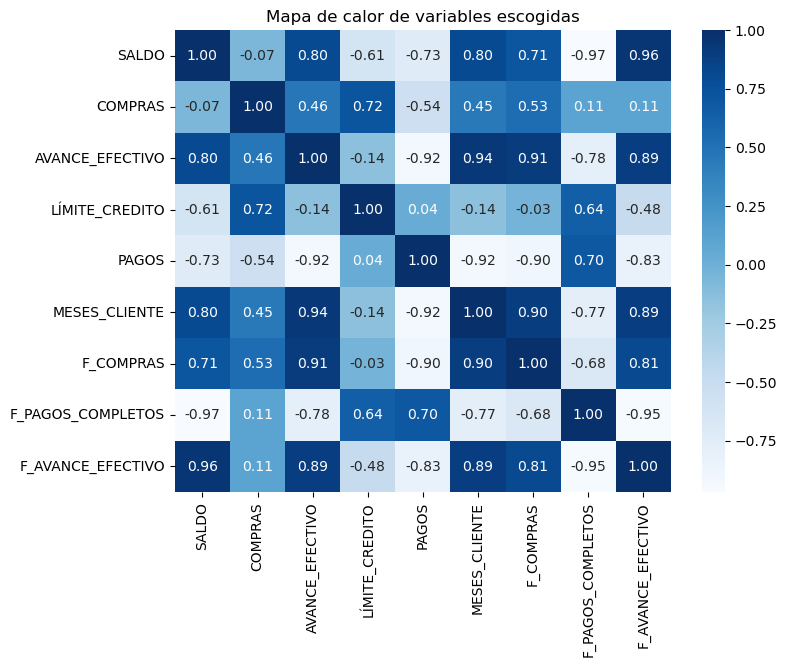

In [45]:
# Calcular la matriz de correlación de las variables seleccionadas
corr_features = customer_df[features].corr()

# Graficar el heatmap con la matriz correcta
plt.figure(figsize=(8,6))
sns.heatmap(corr_features, annot=True, fmt=".2f", cmap="Blues")
plt.title("Mapa de calor de variables escogidas")
plt.show()


## 4. Entrenamiento de modelos

### 4.1 Kmeans

In [ ]:


# Encontrar el número óptimo de clusters con el método del codo
wcss = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("WCSS (Suma de Cuadrados Intra-cluster)")
plt.title("Método del Codo para Determinar K")
plt.show()

# Entrenar el modelo con el número óptimo de clusters (ajustar basado en el gráfico)
k_optimo = 4  # Ajustar manualmente según el método del codo
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(data_scaled)

# Mostrar la cantidad de clientes en cada cluster
print(customer_df["Cluster"].value_counts())

# Ver los centroides del clustering
centroides = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
print("\nCentroides de los clusters:")
print(centroides)

#### 4.1.1. Filtrar variables seleccionadas y escalar datos

In [46]:
# Filtrar las variables seleccionadas
data = customer_df[features]

# Escalar los datos para evitar sesgos en el clustering
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

#### 4.1.2. Encontrar óptimo de clusters con el método del codo

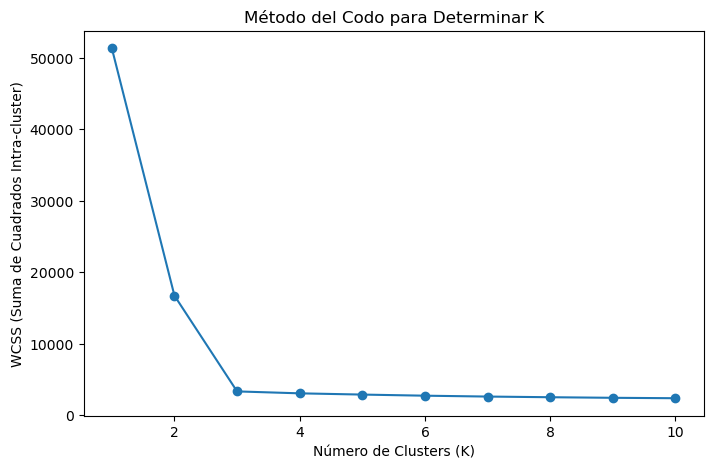

In [49]:
wcss = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("WCSS (Suma de Cuadrados Intra-cluster)")
plt.title("Método del Codo para Determinar K")
plt.show()

Se puede apreciar que el óptimo de clusters es 3

#### 4.1.3. Entrenamiento del modelo

In [50]:
k_optimo = 3  
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(data_scaled)

#### 4.1.4. Mostrar resultados.

In [51]:
print(customer_df["Cluster"].value_counts())

# Ver los centroides del clustering
centroides = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
print("\nCentroides de los clusters:")
print(centroides)

Cluster
1    3171
0    1874
2     659
Name: count, dtype: int64

Centroides de los clusters:
          SALDO       COMPRAS  AVANCE_EFECTIVO  LÍMITE_CREDITO         PAGOS  \
0  13257.823622  40702.242545     37274.849963    14538.379318   8560.712184   
1   4451.126307  29747.057865     11129.239338    15523.980921  24623.728686   
2  16299.681377   7354.556838     21908.671844     4404.854691  20692.737482   

   MESES_CLIENTE  F_COMPRAS  F_PAGOS_COMPLETOS  F_AVANCE_EFECTIVO  
0       9.864995   0.796392           0.363966           0.944997  
1       6.363923   0.425684           0.837494           0.201070  
2       7.819423   0.514481           0.151355           0.944230  


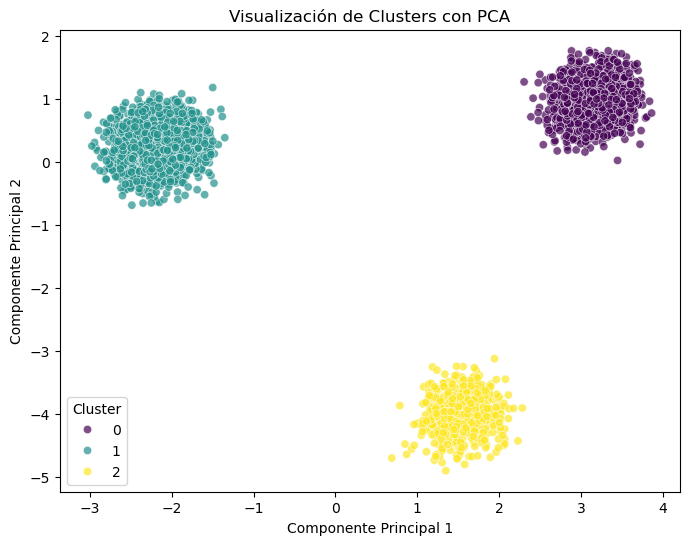

In [52]:
import seaborn as sns
from sklearn.decomposition import PCA

# Aplicar PCA para reducir los datos a 2 dimensiones
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Convertir a DataFrame para graficar
customer_df["PCA1"] = data_pca[:, 0]
customer_df["PCA2"] = data_pca[:, 1]

# Graficar los clusters en el espacio reducido de PCA
plt.figure(figsize=(8,6))
sns.scatterplot(data=customer_df, x="PCA1", y="PCA2", hue="Cluster", palette="viridis", alpha=0.7)
plt.title("Visualización de Clusters con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()
